# VEST Raw Signal SQL Database

## Overview

This notebook is a first-draft shell for documenting how the VAFT pipeline reads 1D raw signals from the VEST MySQL database. It focuses on database structure, shot organization, table and field naming, and the planned interface between database access and Snakemake-managed processing stages.

## Objectives

- Document the VEST MySQL database structure used by VAFT.
- Describe how shots, tables, fields, and time bases are organized.
- Define the planned loading pattern for 1D raw diagnostic signals.
- Identify metadata required by downstream notebook and Snakemake stages.

## Expected Inputs

- Read-only VEST MySQL connection settings or an approved database access profile.
- Shot numbers or shot ranges selected for processing.
- Table names, field names, channel names, and signal units.
- Time-base metadata for each raw signal table.

## Expected Outputs

- A documented database schema map for raw VEST signals.
- Signal-loading conventions for 1D time traces.
- A normalized description of shot, table, field, unit, and time-base metadata.
- Open questions for Snakemake rule inputs and database configuration files.

## Pipeline Context

This notebook belongs to the acquisition and source-data documentation layer of the Snakemake-based VAFT pipeline. Its outputs should eventually define the database-facing contract used before magnetic diagnostics processing, fluctuation analysis, camera synchronization, and shot classification.

## Main Section Headings

### Database Access and Connection Policy

### Shot Index and Metadata Organization

### Table and Field Catalog

### Time-Base and Unit Conventions

### Loading 1D Raw Signals

### Data Quality and Missing-Field Checks

### Snakemake Rule Interface Draft

## Summary

This shell establishes the database documentation entry point for VEST raw signal loading. Implementation will later add schema inspection, example queries, validation checks, and standardized output examples.

## Open Implementation Tasks

- Confirm the authoritative database schema and access method.
- List canonical raw signal tables and required fields.
- Define a reusable signal-loading helper interface.
- Add examples for representative shots without embedding credentials.
- Connect validated outputs to Snakemake configuration and rule inputs.

## Related Notebooks

- `magnetic_diagnostics_processing.ipynb`
- `fluctuation_diagnostics_analysis.ipynb`
- `shot_characteristics_classification.ipynb`
- `fast_camera_video_analysis.ipynb`



## Offline archived SQL/DAQ signal example

The live VEST SQL connection is not required for this example. The archived file `vaft/data/legacy/shot_44740.json.gz` stores raw DAQ field arrays dumped from the SQL-backed loader. The notebook uses `vaft.database.raw.load_raw(..., sample_opt=...)` so the loading interface matches the database path while remaining reproducible offline.


In [ ]:
from pathlib import Path
import gzip
import json
import os
import tempfile

# vaft.database.raw imports matplotlib at module import time. Put the cache in a
# writable location before importing it, which avoids home-directory cache warnings.
mpl_config_dir = Path(tempfile.gettempdir()) / "vaft_matplotlib"
mpl_config_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_config_dir))

import numpy as np
import matplotlib.pyplot as plt

import vaft
from vaft.database import raw
from vaft.data.resources import data_path

SAMPLE_PATH = data_path("legacy/shot_44740.json.gz")

if not SAMPLE_PATH.exists():
    raise FileNotFoundError(f"Archived sample not found: {SAMPLE_PATH}")

print(f"VAFT package: {Path(vaft.__file__).resolve()}")
print(f"Archived raw SQL sample: {SAMPLE_PATH}")


VAFT package: <repo>/vaft/__init__.py
Archived raw SQL sample: <repo>/vaft/data/legacy/shot_44740.json.gz


### Inspect the archived shot

The archive has the same minimal structure produced by `dump_all_raw_signals_for_shot`: a shot number plus per-field DAQ type and waveform samples. Time arrays are reconstructed by `load_raw` from the stored DAQ type.


In [ ]:
with gzip.open(SAMPLE_PATH, "rt", encoding="utf-8") as f:
    shot_archive = json.load(f)

SHOT = int(shot_archive["shot"])
ARCHIVED_FIELDS = shot_archive["fields"]

fast_count = sum(1 for item in ARCHIVED_FIELDS.values() if item.get("type") == "fast")
slow_count = sum(1 for item in ARCHIVED_FIELDS.values() if item.get("type") == "slow")

print(f"Shot: {SHOT}")
print(f"Archived fields: {len(ARCHIVED_FIELDS)}")
print(f"DAQ types: slow={slow_count}, fast={fast_count}")
print(f"Example field codes: {', '.join(list(ARCHIVED_FIELDS)[:20])}")


Shot: 44740
Archived fields: 192
DAQ types: slow=63, fast=129
Example field codes: 1, 5, 12, 13, 18, 19, 20, 21, 24, 25, 26, 27, 28, 59, 60, 61, 62, 63, 64, 65


### Attach field names from the shipped SQL lookup table

The live SQL metadata helper `raw.name(field)` is intentionally not used here because it requires a database connection. Instead, the notebook reads the packaged `sql_table.txt` lookup and joins it to the archived field codes.


In [ ]:
with open(raw.SQL_TABLE_PATH, "r", encoding="utf-8") as f:
    signal_to_field = json.load(f)

field_to_signal = {int(field): name for name, field in signal_to_field.items()}

def signal_name(field: int) -> str:
    return field_to_signal.get(int(field), f"Field {field}")

available_fields = []
for field_text, entry in ARCHIVED_FIELDS.items():
    field = int(field_text)
    data = entry.get("data", [])
    available_fields.append({
        "field": field,
        "daq_type": entry.get("type", "unknown"),
        "samples": len(data),
        "signal": signal_name(field),
    })

available_fields = sorted(available_fields, key=lambda item: item["field"])

print(f"{'field':>5}  {'daq':>5}  {'samples':>7}  signal")
print("-" * 60)
for item in available_fields[:40]:
    print(f"{item['field']:5d}  {item['daq_type']:>5}  {item['samples']:7d}  {item['signal']}")

if len(available_fields) > 40:
    print(f"... {len(available_fields) - 40} more fields available")


field    daq  samples  signal
------------------------------------------------------------
    1   slow    25000  TF Current
    5   slow    25000  PF5 Current
   12   slow    25000  Pressure Raw Data
   13   slow    25000  Pressure
   18   slow    25000  Flux Loop - #3
   19   slow    25000  Flux Loop - #4
   20   slow    25000  Flux Loop - #5
   21   slow    25000  Flux Loop - #6
   24   slow    25000  Flux Loop - #9
   25   slow    25000  Arc Current
   26   slow    25000  Flux Loop - #11
   27   slow    25000  Field 27
   28   slow    25000  Field 28
   59   slow    25000  PF1 Current
   60   slow    25000  PF3 Current
   61   slow    25000  PF4 Current
   62   slow    25000  PF6 Current
   63   slow    25000  PF7 Current
   64   slow    25000  PF9 Current
   65   slow    25000  PF10 Current
   66   fast    25000  MagneticFieldProbe_L-01_Bz
   67   fast    25000  MagneticFieldProbe_L-02_Bz
   68   fast    25000  MagneticFieldProbe_L-03_Bz
   69   fast    25000  MagneticFieldProbe_L

### Load one raw signal through the SQL-compatible path

The primary example uses field `102`, mapped to `Plasma Current`. Passing `sample_opt=str(SAMPLE_PATH)` makes `load_raw` read the archived SQL dump instead of opening a MySQL connection.


In [ ]:
def load_archived_raw(field: int) -> tuple[np.ndarray, np.ndarray]:
    loaded = raw.load_raw(SHOT, field, sample_opt=str(SAMPLE_PATH))
    if loaded is None:
        raise ValueError(f"Field {field} was not loaded from {SAMPLE_PATH}")
    time, data = loaded
    return np.asarray(time, dtype=float), np.asarray(data, dtype=float)

PRIMARY_FIELD = 102
time, plasma_current = load_archived_raw(PRIMARY_FIELD)

print(f"Loaded shot {SHOT}, field {PRIMARY_FIELD}: {signal_name(PRIMARY_FIELD)}")
print(f"time shape = {time.shape}, data shape = {plasma_current.shape}")
print(f"time range = {time[0]:.6f} to {time[-1]:.6f} s")
print(f"data range = {np.nanmin(plasma_current):.6g} to {np.nanmax(plasma_current):.6g}")


Loaded shot 44740, field 102: Plasma Current
time shape = (25000,), data shape = (25000,)
time range = 0.000000 to 0.999960 s
data range = -304733 to 21026.6


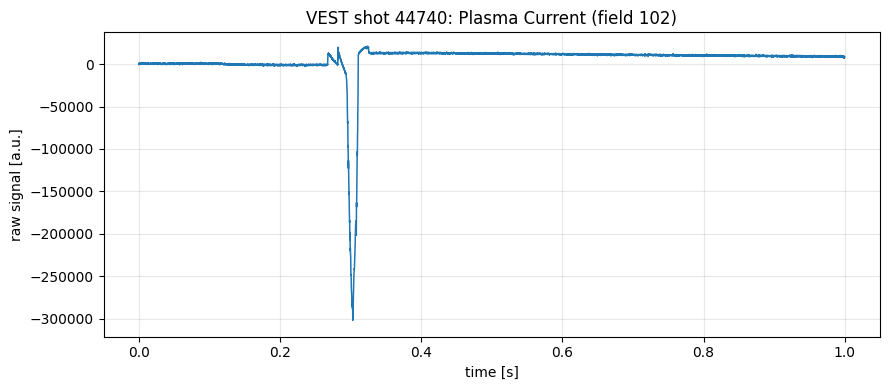

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time, plasma_current, lw=1.1)
ax.set_title(f"VEST shot {SHOT}: {signal_name(PRIMARY_FIELD)} (field {PRIMARY_FIELD})")
ax.set_xlabel("time [s]")
ax.set_ylabel("raw signal [a.u.]")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


### Compare a few archived slow DAQ signals

Multiple fields can be requested at once with the same `load_raw` API. The returned data array has one column per requested field.


time shape = (25000,)
data shape = (25000, 3)


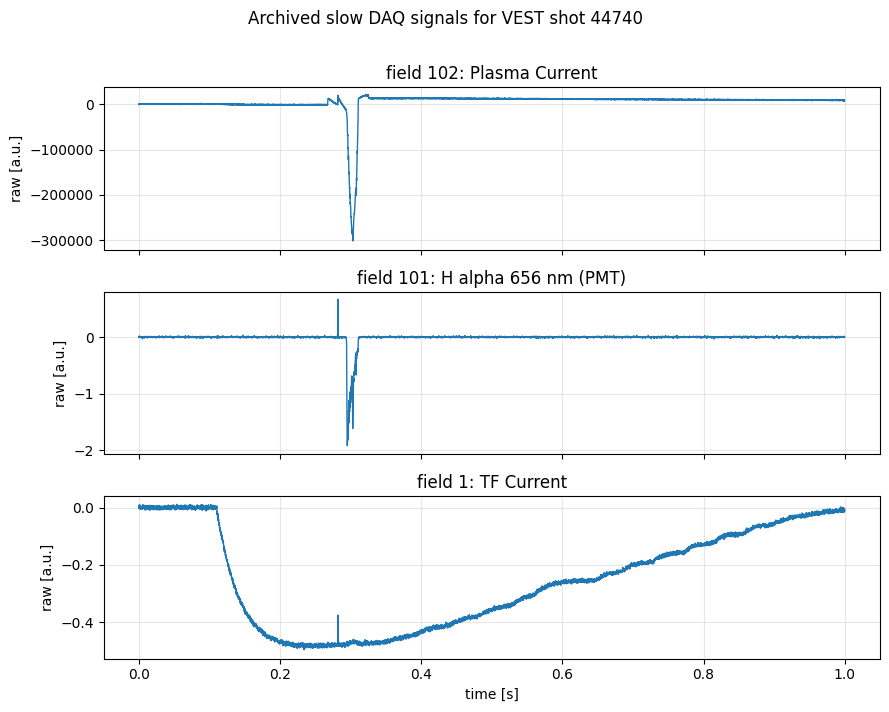

In [ ]:
COMPARISON_FIELDS = [102, 101, 1]
comparison_time, comparison_data = raw.load_raw(
    SHOT,
    COMPARISON_FIELDS,
    sample_opt=str(SAMPLE_PATH),
)

comparison_time = np.asarray(comparison_time, dtype=float)
comparison_data = np.asarray(comparison_data, dtype=float)

print(f"time shape = {comparison_time.shape}")
print(f"data shape = {comparison_data.shape}")

fig, axes = plt.subplots(len(COMPARISON_FIELDS), 1, figsize=(9, 7), sharex=True)
for idx, field in enumerate(COMPARISON_FIELDS):
    axes[idx].plot(comparison_time, comparison_data[:, idx], lw=1.0)
    axes[idx].set_ylabel("raw [a.u.]")
    axes[idx].set_title(f"field {field}: {signal_name(field)}")
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel("time [s]")
fig.suptitle(f"Archived slow DAQ signals for VEST shot {SHOT}", y=1.01)
fig.tight_layout()
plt.show()


### Fast DAQ timing example

Fast DAQ fields reconstruct a shorter time base and include the VEST DAQ trigger correction. For shot `44740`, `raw._daq_trigger_time_correction` shifts fast signals by `0.26 s`.


Loaded shot 44740, field 66: MagneticFieldProbe_L-01_Bz
time shape = (25000,), data shape = (25000,)
time range = 0.260000 to 0.359996 s
expected trigger correction = 0.26 s


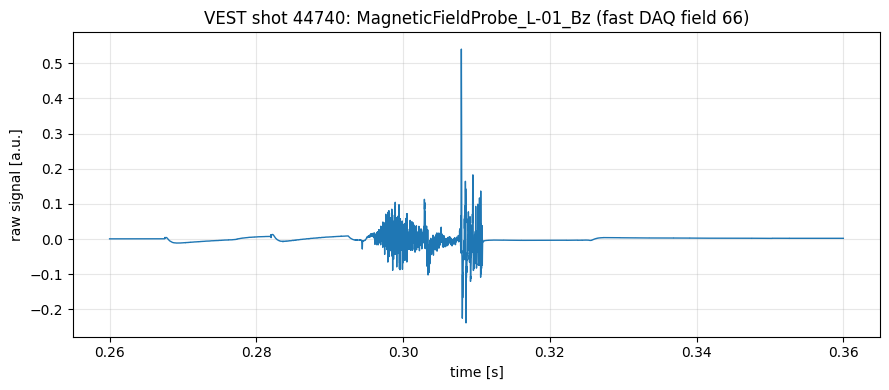

In [ ]:
FAST_FIELD = 66
fast_time, fast_data = load_archived_raw(FAST_FIELD)

print(f"Loaded shot {SHOT}, field {FAST_FIELD}: {signal_name(FAST_FIELD)}")
print(f"time shape = {fast_time.shape}, data shape = {fast_data.shape}")
print(f"time range = {fast_time[0]:.6f} to {fast_time[-1]:.6f} s")
print(f"expected trigger correction = {raw._daq_trigger_time_correction(SHOT):.2f} s")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fast_time, fast_data, lw=1.0)
ax.set_title(f"VEST shot {SHOT}: {signal_name(FAST_FIELD)} (fast DAQ field {FAST_FIELD})")
ax.set_xlabel("time [s]")
ax.set_ylabel("raw signal [a.u.]")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Notes for returning to live SQL

When SQL access is restored, remove `sample_opt=str(SAMPLE_PATH)` from the `load_raw` calls and initialize the raw database configuration/pool as usual. The plotting code above can remain unchanged because it consumes the same `(time, data)` arrays.
